<a href="https://colab.research.google.com/github/christianeiken-coder/Ai-Medical-Physics/blob/main/Kopie_von_week_05_computer_vision_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Chapter 2 - Machine Learning in PyTorch

**This week's exercise has 4 tasks for a total of 6 points (+2 bonus points). Don't forget to submit your solutions to GitHub!**


In this chapter, we want you to become proficient at the following tasks:
- Building a training, validation, and testing script using PyTorch
- Identifying, and being able to build all the typical components of PyTorch model training
- Avoiding, identifying, and fixing typical mistakes in PyTorch model training

#### Chapter 2.5 - PyTorch Modules & Models

Now comes the center piece of training a neural network - the actual neural network.

All we have seen of the neural network so far, is that we stuff a tensor with shape $Batch size * Channels * Height * Width$ into the input, and get a tensor $Batch size * Something$ back out. In our previous example, this something was the number of flower classes. During the course, you have probably been shown what a typical network consists of (things like Convolutional Layers, Fully Connected Layers, Non-Linear Activation Functions, Batch Normalization, etc.), and what these things do, mathematically speaking.

But how do programmers build them? As almost always, the answer is *classes*. Any neural network in PyTorch is a class, which does two things:
- It inherits from a PyTorch class named *torch.nn.Module*.
- It implements an \_\_init\_\_ and a forward method.

The inheritance guarantees that any neural network (and often even its components), follow a common structure. They also guarantee that a lot of useful helper functions, e.g. *model.parameters()*, which lists all weights in a model, are always available to us when we build our own components.

The forward function is implicitly called whenever we stuff something into our model and tell it to make a prediction for us. So, writing `model(data)` or `model.forward(data)` is the same (with very few exceptions). The corresponding backward path, which computes the gradients for each parameter and lets us learn, is mercifully something that PyTorch does *automatically*.

In [ ]:
import numpy
import pandas as pd
import PIL
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as ttf

In [ ]:
# It's time we built a model ourselves.
# Let's start with a model that does *nothing*.

# We start with a class that inherits from torch.nn.Module.
# We want this to have access to a lot of the useful
# automation features which PyTorch offers.
class Example_Model(torch.nn.Module):

    # We want an init method, and at the very least we want
    # to call the init function of our parent class aswell.
    def __init__(self):
        super(Example_Model, self).__init__()

    # We also want a forward method.
    def forward(self, x):
        return x

# We make an instance of our model, ...
my_first_model = Example_Model()

# ... quickly grab an example "image" to feed in, ...
random_noise = torch.rand((16, 1, 256, 256))

# ... and tell our model to make a forward pass.
# Of course, this prediction is currently bogus.
prediction = my_first_model(random_noise)

print(prediction.size())

torch.Size([16, 1, 256, 256])


In [ ]:
# And that's already it!

# ... or is it?
# So far, our model has not done anything, of course, it just spat
# our input tensor back out. Let's give it some learnable parameters.

class Example_Model(torch.nn.Module):

    def __init__(self):
        super(Example_Model, self).__init__()

        # This time, we specify some components.
        # You could write components yourself, but in practice,
        # PyTorch has pretty much all you will ever need.

        # Linear is the name of the fully connected layer in PyTorch,
        # the one you know from MLPs already.
        # The number of in-going signals will be as many as we have
        # pixels in our toy model.
        # The number of out-going features is up to our choosing.
        self.fc1 = torch.nn.Linear(in_features = 1*(256**2), out_features = 3)

        # We will learn more about these components in a little bit.

    def forward(self, x):
        # To turn the image from 2D into "1D" for the fully connected
        # layer, we use the flatten() method.
        # Remember that when we flatten our tensor, we only flatten the image,
        # not the batch dimension, or else we start mixing images together!
        x = x.flatten(start_dim = 1)
        # This time, we actually use our predefined layer in our
        # forward pass.
        x = self.fc1(x)
        return x

my_second_model = Example_Model()
random_noise = torch.rand((16, 1, 256, 256))
prediction = my_second_model(random_noise)
print(prediction.size())

torch.Size([16, 3])


In [ ]:
# You can also look at what building blocks your model is composed of:
print(my_second_model)

Example_Model(
  (fc1): Linear(in_features=65536, out_features=3, bias=True)
)


In [ ]:
# and what your parameters currently are:
for name, param in my_second_model.named_parameters():
    print(f"{name}: {param}")

fc1.weight: Parameter containing:
tensor([[-8.5157e-04,  2.7171e-03, -3.6027e-03,  ..., -1.5167e-03,
          3.1969e-03, -4.7857e-05],
        [ 9.1037e-04, -8.3575e-04, -2.7733e-03,  ..., -3.5671e-03,
         -6.8409e-04,  2.4632e-03],
        [ 6.0744e-04,  1.8715e-03, -5.7736e-04,  ...,  1.1122e-03,
         -3.5365e-03, -2.9093e-03]], requires_grad=True)
fc1.bias: Parameter containing:
tensor([-0.0006, -0.0004, -0.0010], requires_grad=True)


For those who want to dive deeper:

When we wrote `self.fc1 = nn.Linear(...)`, we added a module to our model (duh), and the class can henceforth refer to this module by its name (e.g. `x = self.fc1(x)` works). The model also knows to collect gradients for and to update the parameters of these modules. If you want to build sophisticated models, sometimes you will not handcraft everything, but rather make a couple of building blocks, and want to add a variable number of them to your model. For such cases, there is a function named `self.add_module(name, child_module)`. In essence, the following two things are equivalent:
- `self.add_module("fc1", nn.Linear(...))`
- `self.fc1 = nn.Linear(...)`

However, sometimes it is very convenient being able to fill in the left side of the equation dynamically.

#### Chapter 2.6 - Model Lego

In the preceding weeks of the seminar, you have probably learnt about some of the concepts behind neural networks. If not, or if you do not remember, here is a little crash course on what building blocks we have, how they work, and how we can easily conceptualize what they do.

There are far more things that PyTorch can do, and it would be quite impossible to showcase all of them here. Others, like BatchNorm, we will learn about as we implement architectures from the more recent neural network milestone papers. If you come across something you haven't heard before in a paper, or have an idea for something you'd like to try, there is a good chance that you can find this operation already fully implemented in PyTorch - try googling it! You will find that the PyTorch documentation is quite good, and that you can discover some very useful features this way.

**Linear layers** - The simplest and oldest component of a neural network is the Linear layer, often called a Fully Connected layer. A fully connected layer is defined by a number of in-going and out-going connections. The number of in-going connections, naturally, is the same as the number of out-going connections from the layer before. The number of out-going connections can be is chosen so that every node in our layer is connected to every node in the following layer.

The Linear layer is called linear because each out-going signal equals the sum of all products of a node's weight and in-going signal, plus a bias term per node:
$y_i = \sum_{j} w_{ij}* x_j + b_i$

This makes it, mathematically speaking, a linear transformation plus a translation (also called an affine transformation):
$y = x*A^T +b$

In [ ]:
# In PyTorch, a Linear layer that takes 20 input signals and gives 10 output signals is made like this:

fc1 = torch.nn.Linear(in_features = 20, out_features = 10)

**Activation functions** - Where neural networks are concerned, Linear layers are nice, but come with an inherent problem: Any combination of two affine transformations, is itself an affine transformation. Consequently, neural networks do not really gain much from multiple Linear layers that one Linear layer couldn't have done, and also generally have trouble capturing higher-order polynomial dependencies in data.

However, there is a solution to this problem! A so-called activation function is commonly added after every Linear layer (and typically also after convolutions, which we will get to later), and its purpose is to introduce some form of non-linear transformation between our affine transformations. The combination `Affine + Affine` can be expressed as a single Affine, so it can encode the information of only one Affine Transformation. The combination `Affine + Non-linear function + Affine` cannot be expressed as a single Affine anymore. In this case, having two separate Affine Transformations is suddenly useful, and the issues capturing non-linear and particularly higher-order polynomial dependencies are lessened.

There is a multitude of different activation functions, and historically, different ones have been used for different reasons. The most common among these activation functions are:
- Tangens Hyperbolicus: $tanh(x) = \frac{e^{2x}-1}{e^{2x}+1}$
- Sigmoid: $\sigma(x) = \frac{1}{(1+e^{-x})}$
- ReLU: $R(x) = \{0 $ if $ x<0 $, else $ x\}$
- Swish: $S(x) = \frac{x}{(1+e^{-ßx})}$

All of them have different advantages and disadvantages, although in most modern neural networks, you don't really feel either of them:
- Sigmoid and Tanh are smooth, non-linear functions. In some cases, this affords you smoother outputs with fewer kinks. As a potential downside, the activations saturate for large absolute values (see plot). If our weights are large enough, this can create problems: Suddenly, all our activations look similar, even for very different inputs. This is typically very undesirable, and can cause models to stop learning.
- ReLU has no continuous non-linearity, only a single point (zero) at which the function is not continuous. It is somewhat weaker in capturing non-linear dependencies as a result. However, it has really friendly and smooth gradients, which makes training with ReLU very stable and reliable. If your model ever doesn't learn, it's probably not ReLU's fault.
- Swish is a modern activation function that was found by systematically testing random combinations or chains of functions and observing how they performed as activation functions. It looks very similar to ReLU and approaches ReLU for large absolute values, but has a smooth non-linearity around 0 instead of a kink. Generally, it has the same advantages as ReLU, and is said to have the same downsides except less pronounced. There are many other brands of "ReLU but slightly different" out there. If you're ever looking to squeeze out the final few drops of performance from your model, it can be worth checking them out.

The most important things are this: Firstly, all activation functions have at least one non-linearity, sometimes even a big continuous one, and typically they are near zero. Secondly, most have a region where they function best. Take for example, the sigmoid, which neatly differentiates inputs near zero, but provides almost the same output for inputs that are very large or small. Typically this region is also near zero.

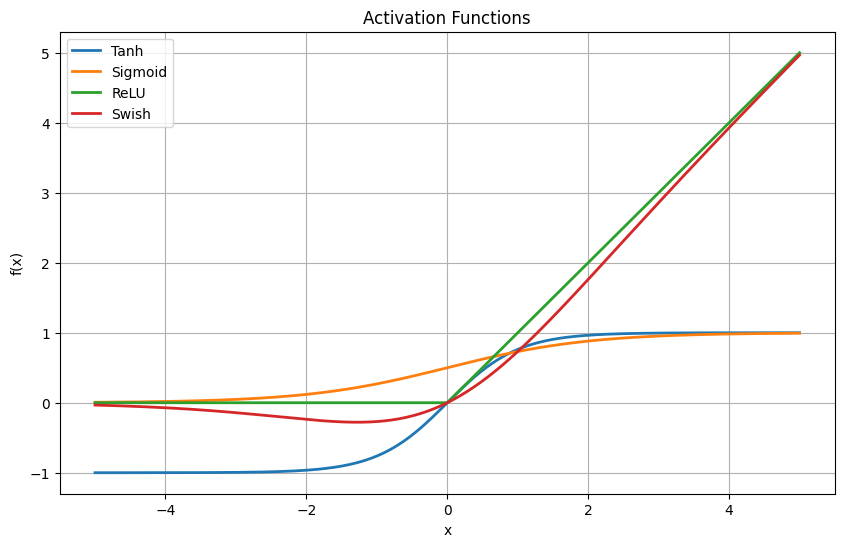

In [ ]:
# Here are some plots for the various functions:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions
def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def swish(x):
    return x * sigmoid(x) # ß = 1

# Create an array of x values
x = np.linspace(-5, 5, 400)

# Calculate y values for each function
y_tanh = tanh(x)
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_swish = swish(x)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y_tanh, label='Tanh', linewidth=2)
plt.plot(x, y_sigmoid, label='Sigmoid', linewidth=2)
plt.plot(x, y_relu, label='ReLU', linewidth=2)
plt.plot(x, y_swish, label='Swish', linewidth=2)

plt.title('Activation Functions')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# In PyTorch, these functions can be invoked via:

# This is a class instance of the ReLU class
relu = torch.nn.ReLU()

# It does almost nothing except apply the ReLU function to
# your tensor, and being almost everywhere differentiable.
some_tensor = torch.randn((16,3,256,256))
some_tensor = relu(some_tensor)

**Convolution layers** - Conceptually, you can imagine a convolution operation as asking the question 'Where on my image do I have the feature **f**'? The (typical 2D) convolution operator (or kernel) is a tensor of shape M x N. The convolution operation assigns the value of a pixel in the result image by computing the element-wise product of our input image in an area around a so-called *anchor pixel* and the convolution kernel, and then summing. This process is repeated for all pixels in the original image:  
  
$I_{new}[x, y] = (I * K)[x, y] = \sum_{a}\sum_{b} K[a, b]*I[x - a, y - b]$  
  
with $I$ being our original image, $I_{new}$ being the result image, and $K$ being the convolution kernel.
*In layman's terms, if you draw a little circle into the kernel, then the result of convolving the input image is a map of where in the input image you can find circles like the one in the kernel*. It is therefore often called a *feature map* or an *activation map*.

In a modern neural network, convolutional layers are ubiquitous. The computer will, over the course of the training, adapt the contents of the convolution kernels in order to best represent and categorize the images it sees. Features in early convolutional layers correspond to the actual content of the image and make intuitive sense to a human observer - to classify cars, you can expect to be needing a couple of differently angled straight lines, some smooth curves, and circles for the wheels, for example. The features in later layers are less (or not at all) interpretable to human eyes. At that point, the image that the computer has, typically consists of activation maps of activation maps of activation maps of ... well, you get the gist.

It is still possible to visualize what these represent, and some of the features are surprisingly human-interpretable (such as an entire car wheel, or the texture of a brick wall), while others look like LSD-induced hallucinations. If we have some time at the end of the course, we may try our hands at this visualization ourselves, and take a look at how your neural networks see the world.

Convolution operations are defined by their number of in-going and out-going signal channels. At the beginning of a neural network, the in-going channel number is typically 3 (for RGB images) or 1 (for grayscale images). The out-going channel number can be freely chosen. Convolution operations can have any kernel size, but typically its height and width are chosen as odd numbers. This is done because the convolution kernel is applied to the area around the anchor pixel in our original image - a kernel with odd dimensions can be centered exactly on this anchor, while one with even dimensions can not. The latter case causes interesting systematic errors, which are fun to look at, but have a tendency to ruin the performance of the neural network.

In [ ]:
# In PyTorch, Convolutions can be invoked by setting them
# up as an instance of the various classes PyTorch offers:

# This is a class instance of the 2D Convolution class from PyTorch
conv = torch.nn.Conv2d(in_channels = 3, out_channels = 8, kernel_size = (3, 3))

# It applies a convolution kernel of size 3x3 across 3 input channels and for 8 output channels
some_tensor = torch.randn((16,3,256,256))
print(some_tensor.size())
some_tensor = conv(some_tensor)
print(some_tensor.size())

torch.Size([16, 3, 256, 256])
torch.Size([16, 8, 254, 254])


**Pooling operations** - Conceptually, a pooling operation is quite simple. We compute a new image from a pooling operation by starting at a pixel, and applying the pooling operator to the pixel and its surroundings. The result is the value of the a new pixel. This process is repeated for every pixel in the image and you get a new image. Typically, the pooling operator either performs the max() or the mean() operation on the area it is applied to. These specific pooling ops are name MaxPool and AvgPool, respectively.

Very often, something called a 'stride' is applied during the pooling operation. 'A stride of *s*' means that in order to get a new image, we do not iterate over every pixel and perform pooling on its respective surrounding, but that we instead skip *s* rows and columns on each step. Typically, stride and pooling operator shapes are chosen to be the same, so that no pixel is ignored during the calculations, and so that no pixel contributes to the new image more than once. Consequently, the new image after a pooling operation will be downscaled by a factor *s*. Since, in a sense, the new image still contains *all, or most of the relevant* information from the original image, strided pooling is often used for exactly this downscaling effect. This reduces the amount of computation needed for later steps, and helps extracting the most relevant information from an image.

If you try to imagine applying a 2x2 pooling operator to, say, a 5x5 image, do you notice a problem? No matter how you define the 2x2 surrounding of your current pixel, some pixels you need to calculate the result of the pooling operator will not exist - they would be outside the bounds of our image! This is a very common occurence, and pooling operations perform something called *padding*. Padding extends the image by the necessary pixels, just for the calculations of pixels that actually exist. Typically, the image is extended using pixels which exclusively have the values zero, although other paddings exist. Convolution operations sometimes do the same thing, for the same reason.

In [ ]:
# In PyTorch, these pooling operations can be invoked via:

# This is a class instance of the MaxPool2d class
max_pool = torch.nn.MaxPool2d(kernel_size = (2, 2), stride = 2)

# It does almost nothing except apply the ReLU function to
# your tensor, and being differentiable.
some_tensor = torch.randn((16,3,256,256))
some_tensor = max_pool(some_tensor)

And now it's your turn.

**Task 1 (2 points)**: Try to make a model that performs mathematical operations that you've learned about in the course. For example, try adding in a convolutional layer or two, a fully connected layer or two, and nonlinearities such as ReLUs or tanhs.

Let's prepare ourselves to make a model for the LiTS 2017 classification task that we've already previously talked about. All the model has to do is take the dummy batch below as input (batch size 16, three channels, 256 by 256 pixels), and produce an output of the shape B x 3, for the three classes Nothing, Liver, Liver+Tumor. It doesn't have to be good, or clever, or work particularly well for now. All we want is for you to get a feeling for the various layers we discussed, how to manipulate your input tensors into different shapes, and which input and output shapes a tensor will have after you add a specific layer.

**Task 2 (1 point)**: Where in a convolutional neural network would you use a fully connected layer, if at all, and where shouldn't you? Why?

**Task 3 (1 point)**: Which shape do convolution layer weights have if the input image has more than one input and output channel? To show that you understand the math properly, explain in simple terms why it must have this shape. A visual explanation probably works best. (You can look the shape up in your own code, if you don't know.)

In [ ]:
# This dummy batch (batch size 16, 3 channels, 256x256 pixels)
# will be your input. Try to see if the output of your model is
# what you expected it to be.
dummy_batch = torch.rand((16, 3, 256, 256))

# Remember that you can use some_tensor.size() to check the
# current dimensions of your tensor, so that you keep track of
# what the things you've just added do.

In [ ]:
# One possible solution:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms.functional as ttf
import pandas as pd
import torchvision
import torch
from PIL import Image

class LiTS_Dataset(Dataset):

    """
    For our sample solution, we go for the easier variant.

    In this specific dataset, we don't load the images until we need them - for a
    short training, or limited resources, this is good behavior. If you have the
    necessary RAM to pre-load all of your data, you don't have to load the data
    multiple times, and save compute costs in the long run. The downside is that
    when you are trying to debug, you wait for ages every time, and if you simply
    do not have the compute resources, you can't even do it.
    """

    def __init__(self, csv: str, mode: str):

        self.csv = csv
        self.data = pd.read_csv(self.csv)
        self.mode = mode
        assert mode in ["train", "val", "test"] # has to be train, val, or test data - if not, assert throws an error

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        file = self.data.loc[idx, "filename"]
        with PIL.Image.open(f"./Clean_LiTS/{self.mode}/{file}") as f:
            f = f.convert("L")
            image = ttf.pil_to_tensor(f)

        # PNG images have an integer range from 0 to 255, typically.
        # CT images often have a slightly uncommon 12-bit, or a 16-bit integer range,
        # where each value is the X-ray absorption at that point in the image, measured
        # in Hounsfield Units. These go from -1000 for air, over 0 for things like water
        # to one or several thousand for dense objects like thick bone or metal. Values
        # are typically capped between -1024 to 3071 (for 12 bits).

        # Since we already know that models generally want floating point numbers to
        # work, and activation functions work best around 0, data is often normalized
        # to this range. This is done either by forcing the values into the [0, 1]
        # interval, or multiplying it such that all values approximately form a Gaussian
        # distribution with mean 0 and standard deviation 1. Here, we opt for the
        # [0, 1] variant.
        image = image.to(dtype = torch.float32)
        image -= torch.min(image)
        image /= torch.max(image)

        liver_visible = self.data.loc[idx, "liver_visible"]
        lesion_visible = self.data.loc[idx, "lesion_visible"]
        # Note that targets must have the data type torch.long - a 64-bit integer,
        # unlike the image tensor, which is usually a 32-bit float, the default
        # dtype for tensors when none is given
        if lesion_visible and liver_visible:
            target = torch.tensor(2, dtype = torch.long)
        elif not lesion_visible and liver_visible:
            target = torch.tensor(1, dtype = torch.long)
        elif not lesion_visible and not liver_visible:
            target = torch.tensor(0, dtype = torch.long)
        else:
            print(
                idx,
                lesion_visible,
                liver_visible,
                self.data.loc[idx, "liver_visible"],
                self.data.loc[idx, "lesion_visible"],
                self.data.loc[idx, "filename"]
                )
            raise ValueError("Invalid target")

        return image, target

train_ds = LiTS_Dataset("/Users/christianeiken/ml_env/Clean_LiTS/train_classes.csv", mode="train")
val_ds   = LiTS_Dataset("/Users/christianeiken/ml_env/Clean_LiTS/val_classes.csv",   mode="val")
test_ds  = LiTS_Dataset("/Users/christianeiken/ml_env/Clean_LiTS/test_classes.csv",  mode="test")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/christianeiken/ml_env/Clean_LiTS/train_classes.csv'

#### Chapter 2.7 - Putting it all together

We have all the pieces. We have a recipe, with which we can train a model using some data. We have made ourselves a dataset, using the LiTS data, last week. And we know how to make our own, small, CNN models.

**Task 4 (2 points + 2 bonus points)**: Stitch together all the individual parts that you have built and classify the LiTS 2017 data into the three classes NOTHING (0), LIVER (1), LIVER+TUMOR (2). You are allowed to just copy your previous solutions. Try using as many of the things you have learnt about as possible, and see if your neural network is capable of training to recognize liver cancer. You script has to do the following things:
- Use your own dataset of LiTS 2017.
- Use your own model from before.
- Train your own model.
- Use your own hyperparameters, if any. If you use hyperparameters or settings we have not discussed before, be ready to explain them to us.

Whichever group gets the best results (you can build some different models and try out hyperparameters of your choosing), **gets 2 bonus points**. :v)

If the loss goes down and your model's predictions are better than random guesses or all-zero guesses, the task is considered solved. All-zero guesses refers to the model always predicting "No Liver, No Tumors", which is typically class number 0 - this is a common failure mode for this task, and would not count. To check whether your solution works, take a look at your model's predictions.

Below are some tips, things that students have had trouble with in the past, what they did and how you can spot whether you're accidentally doing them:
- **Model loss never goes down** - Is your model always trainable, or did you put a model.eval() somewhere and never go back to model?train()? If you forget this, you never track gradients and consequently cannot learn. If the loss is always the same, very specific number, and your model is definitely trainable, it may also be something else. Maybe your model performs a softmax operation on its output, but the loss also does?
- **Training loss immediately goes to zero** - You may be accidentally feeding your model the correct solutions as part of the input. Basically, the model "cheats" but never learns anything.
- **Predictions are all the same class, loss is not going down or not a lot** - Your model is probably capable of learning, because this does not happen randomly, but it's probably not very good at learning. The issue is likely in the model class.

In [2]:
# Download our data again:
!gdown 1TItTaso19GFTPdDnynVnqJvHsCm_RGlI
!rm -rf ./sample_data/
!unzip -qq Clean_LiTS.zip
!rm ./Clean_LiTS.zip

Downloading...
From (original): https://drive.google.com/uc?id=1TItTaso19GFTPdDnynVnqJvHsCm_RGlI
From (redirected): https://drive.google.com/uc?id=1TItTaso19GFTPdDnynVnqJvHsCm_RGlI&confirm=t&uuid=1b6b27dd-1f0e-471c-a57d-1b8c32710996
To: /content/Clean_LiTS.zip
100% 2.56G/2.56G [00:37<00:00, 67.6MB/s]


In [20]:
# One possible solution:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms.functional as ttf
import pandas as pd
import torchvision
import torch
from PIL import Image

class LiTS_Dataset(Dataset):


    def __init__(self, csv: str, mode: str, transform=None):

        self.csv = csv
        self.transform = transform
        self.data = pd.read_csv(self.csv)
        self.mode = mode
        assert mode in ["train", "val", "test"]

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        file = self.data.loc[idx, "filename"]
        with PIL.Image.open(f"./Clean_LiTS/{self.mode}/{file}") as f:
            f = f.convert("L")
            image = ttf.pil_to_tensor(f)

        image = image.to(dtype = torch.float32)
        image -= torch.min(image)
        image /= torch.max(image)

        liver_visible = self.data.loc[idx, "liver_visible"]
        lesion_visible = self.data.loc[idx, "lesion_visible"]

        if lesion_visible and liver_visible:
            target = torch.tensor(2, dtype = torch.long)
        elif not lesion_visible and liver_visible:
            target = torch.tensor(1, dtype = torch.long)
        elif not lesion_visible and not liver_visible:
            target = torch.tensor(0, dtype = torch.long)
        else:
            print(
                idx,
                lesion_visible,
                liver_visible,
                self.data.loc[idx, "liver_visible"],
                self.data.loc[idx, "lesion_visible"],
                self.data.loc[idx, "filename"]
                )
            raise ValueError("Invalid target")

        if self.transform:
          image = self.transform(image)


        return image, target

import torchvision.transforms as T

train_tf = T.Compose([
    T.RandomRotation(10),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomAffine(10, scale=(0.95, 1.05)),
])
# hier machen wir Data Augmentation. Es kommt aus dem Englischen und heißt soviel wie etwas verändern. Das heißt wir nehmen unsere Rohdaten und spiegeln/ drehen etc. diese.

train_ds = LiTS_Dataset("/content/Clean_LiTS/train_classes.csv",mode="train", transform=train_tf) #Wir wollen hier nur die Trainingsdaten ändern
val_ds   = LiTS_Dataset("/content/Clean_LiTS/val_classes.csv",   mode="val")
test_ds  = LiTS_Dataset("/content/Clean_LiTS/test_classes.csv",  mode="test")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

labels = []
for idx, row in train_ds.data.iterrows():
    liver_visible = row["liver_visible"]
    lesion_visible = row["lesion_visible"]

    if lesion_visible and liver_visible:
        labels.append(2)
    elif not lesion_visible and liver_visible:
        labels.append(1)
    elif not lesion_visible and not liver_visible:
        labels.append(0)
    else:
        raise ValueError("Invalid target")

labels = np.array(labels)
class_counts = np.bincount(labels)

print("Klassenhäufigkeiten:", class_counts)


Klassenhäufigkeiten: [24274  7085  4125]


In [21]:
import torch.nn as nn

class Really_Good_Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        # your input is grayscale (1 channel)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # after two pools → 256->128->64
        self.fc1 = nn.Linear(32 * 64 * 64, 128)
        self.fc2 = nn.Linear(128, 3)   # 3 Klassen!

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


#

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HighPerformanceCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ---- Block 1 ----
        self.conv1a = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1a   = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1b   = nn.BatchNorm2d(32)

        # Output size nach Block 1: 32 x 256 x 256
        self.pool1 = nn.MaxPool2d(2)   # -> 32 x 128 x 128

        # ---- Block 2 ----
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2a   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)

        # -> 64 x 128 x 128
        self.pool2 = nn.MaxPool2d(2)   # -> 64 x 64 x 64

        # ---- Block 3 ----
        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3a   = nn.BatchNorm2d(128)

        # -> 128 x 64 x 64
        self.pool3 = nn.MaxPool2d(2)   # -> 128 x 32 x 32

        # ---- Fully Connected Layers ----
        self.flatten_dim = 128 * 32 * 32   # = 131072

        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 3)   # 3 Klassen (0, 1, 2)

    def forward(self, x):

        # Block 1
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.bn3a(self.conv3a(x)))
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC Layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss


model = HighPerformanceCNN().to(device)

class_weights = 1.0 / class_counts #wir haben oben die Klassenhäufigkeiten uns ausgeben lassen: Klassenhäufigkeiten: [24274  7085  4125].
class_weights = class_weights / class_weights.sum() * len(class_weights)  # optional normalisieren

print("Class Weights:", class_weights)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device) #Data Augmentation von oben war alleine leider nciht die Lösung.
                                            # also versuchen wir es jetzt mit Bias

loss_criterion = FocalLoss(alpha=class_weights_tensor, gamma=2)
 # hier kommt dann jetzt die Gewichutng der klassen rein
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Class Weights: [0.29095938 0.99685928 1.71218134]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [1/5]  Step [1/1108]  Loss: 0.6051
Epoch [1/5]  Step [51/1108]  Loss: 0.2303
Epoch [1/5]  Step [101/1108]  Loss: 0.2826
Epoch [1/5]  Step [151/1108]  Loss: 0.1867
Epoch [1/5]  Step [201/1108]  Loss: 0.2472
Epoch [1/5]  Step [251/1108]  Loss: 0.1703
Epoch [1/5]  Step [301/1108]  Loss: 0.1103
Epoch [1/5]  Step [351/1108]  Loss: 0.2174
Epoch [1/5]  Step [401/1108]  Loss: 0.1864
Epoch [1/5]  Step [451/1108]  Loss: 0.1591
Epoch [1/5]  Step [501/1108]  Loss: 0.1915
Epoch [1/5]  Step [551/1108]  Loss: 0.1593
Epoch [1/5]  Step [601/1108]  Loss: 0.2841
Epoch [1/5]  Step [651/1108]  Loss: 0.3174
Epoch [1/5]  Step [701/1108]  Loss: 0.1562
Epoch [1/5]  Step [751/1108]  Loss: 0.0539
Epoch [1/5]  Step [801/1108]  Loss: 0.7630
Epoch [1/5]  Step [851/1108]  Loss: 0.2177
Epoch [1/5]  Step [901/1108]  Loss: 0.0851
Epoch [1/5]  Step [951/1108]  Loss: 0.3031
Epoch [1/5]  Step [1001/1108]  Loss: 0.0681
Epoch [1/5]  Step [1051/1108]  Loss: 0.1321
Epoch [1/5]  Step [1101/1108]  Loss: 0.1388
Epoch: 1,  

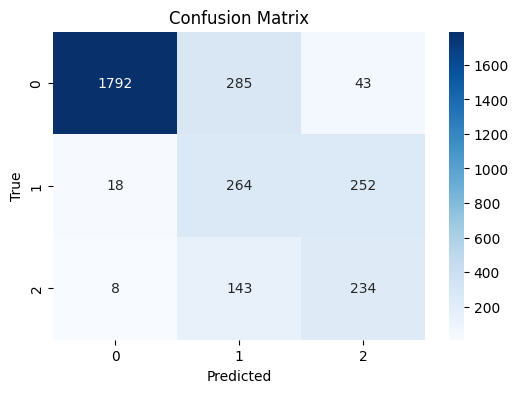

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [2/5]  Step [1/1108]  Loss: 0.0723
Epoch [2/5]  Step [51/1108]  Loss: 0.1146
Epoch [2/5]  Step [101/1108]  Loss: 0.0875
Epoch [2/5]  Step [151/1108]  Loss: 0.0856
Epoch [2/5]  Step [201/1108]  Loss: 0.0222
Epoch [2/5]  Step [251/1108]  Loss: 0.1063
Epoch [2/5]  Step [301/1108]  Loss: 0.0902
Epoch [2/5]  Step [351/1108]  Loss: 0.0789
Epoch [2/5]  Step [401/1108]  Loss: 0.2341
Epoch [2/5]  Step [451/1108]  Loss: 0.2361
Epoch [2/5]  Step [501/1108]  Loss: 0.2134
Epoch [2/5]  Step [551/1108]  Loss: 0.1083
Epoch [2/5]  Step [601/1108]  Loss: 0.0668
Epoch [2/5]  Step [651/1108]  Loss: 0.1058
Epoch [2/5]  Step [701/1108]  Loss: 0.1732
Epoch [2/5]  Step [751/1108]  Loss: 0.0650
Epoch [2/5]  Step [801/1108]  Loss: 0.1259
Epoch [2/5]  Step [851/1108]  Loss: 0.0765
Epoch [2/5]  Step [901/1108]  Loss: 0.0780
Epoch [2/5]  Step [951/1108]  Loss: 0.0620
Epoch [2/5]  Step [1001/1108]  Loss: 0.2579
Epoch [2/5]  Step [1051/1108]  Loss: 0.1212
Epoch [2/5]  Step [1101/1108]  Loss: 0.2510
Epoch [3/5]

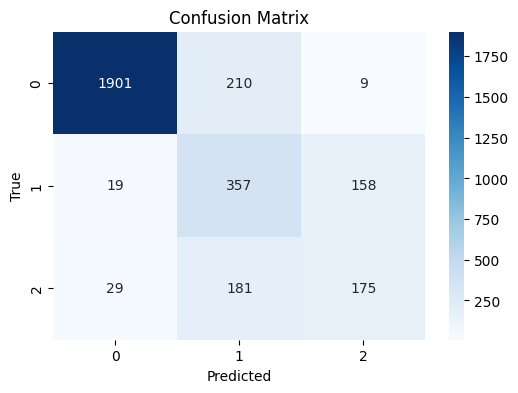

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [4/5]  Step [1/1108]  Loss: 0.1855
Epoch [4/5]  Step [51/1108]  Loss: 0.0766
Epoch [4/5]  Step [101/1108]  Loss: 0.0905
Epoch [4/5]  Step [151/1108]  Loss: 0.0925
Epoch [4/5]  Step [201/1108]  Loss: 0.1263
Epoch [4/5]  Step [251/1108]  Loss: 0.0542
Epoch [4/5]  Step [301/1108]  Loss: 0.0540
Epoch [4/5]  Step [351/1108]  Loss: 0.0420
Epoch [4/5]  Step [401/1108]  Loss: 0.1574
Epoch [4/5]  Step [451/1108]  Loss: 0.1996
Epoch [4/5]  Step [501/1108]  Loss: 0.0841
Epoch [4/5]  Step [551/1108]  Loss: 0.0479
Epoch [4/5]  Step [601/1108]  Loss: 0.0696
Epoch [4/5]  Step [651/1108]  Loss: 0.1737
Epoch [4/5]  Step [701/1108]  Loss: 0.1193
Epoch [4/5]  Step [751/1108]  Loss: 0.3050
Epoch [4/5]  Step [801/1108]  Loss: 0.1160
Epoch [4/5]  Step [851/1108]  Loss: 0.0529
Epoch [4/5]  Step [901/1108]  Loss: 0.1005
Epoch [4/5]  Step [951/1108]  Loss: 0.0481
Epoch [4/5]  Step [1001/1108]  Loss: 0.1014
Epoch [4/5]  Step [1051/1108]  Loss: 0.0578
Epoch [4/5]  Step [1101/1108]  Loss: 0.1841
Epoch [5/5]

In [ ]:
# DataLoader richtig bauen
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms.functional as ttf
import pandas as pd
import torchvision
import torch
from PIL import Image
import PIL.Image

batch_size = 32

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=batch_size,
    num_workers=4,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_ds,
    batch_size=batch_size,
    num_workers=0,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=batch_size,
    num_workers=0,
    shuffle=False,
    drop_last=False
)

num_epochs = 5

for epoch in range(num_epochs):

    # -------------------------
    #        TRAINING
    # -------------------------
    for step, (data, targets) in enumerate(train_loader):

        optimizer.zero_grad()

        data, targets = data.to(device), targets.to(device)

        predictions = model(data)
        loss = loss_criterion(predictions, targets)

        if step % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]  Step [{step+1}/{len(train_loader)}]  Loss: {loss.item():.4f}")

        loss.backward()
        optimizer.step()

    # -------------------------
    #       VALIDATION
    # -------------------------
    if epoch % 2 == 0:
        model.eval()
        with torch.no_grad():

            hits = 0
            losses = []
            batch_sizes = []

            all_preds = []
            all_targets = []

            for step, (data, targets) in enumerate(val_loader):
                data, targets = data.to(device), targets.to(device)

                predictions = model(data)
                loss = loss_criterion(predictions, targets)

                losses.append(loss.item())
                batch_sizes.append(data.size(0))

                class_predictions = torch.argmax(predictions, dim=1).flatten()
                hits += (class_predictions == targets).sum().item()

                # sammeln für spätere Analyse
                all_preds.extend(class_predictions.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        avg_loss = sum([l * bs for l, bs in zip(losses, batch_sizes)]) / sum(batch_sizes)
        accuracy = hits / len(val_ds)

        print(f"Epoch: {epoch+1},  Validation Loss: {avg_loss:.4f},  Accuracy: {accuracy:.4f}")

        # ------------------------------------------------
        #   🔥 1. Klassenweise Accuracy
        # ------------------------------------------------
        import numpy as np
        all_preds_np = np.array(all_preds)
        all_targets_np = np.array(all_targets)

        num_classes = len(np.unique(all_targets_np))
        class_correct = [0] * num_classes
        class_total   = [0] * num_classes

        for t, p in zip(all_targets_np, all_preds_np):
            class_total[t] += 1
            if t == p:
                class_correct[t] += 1

        print("\nClasswise Accuracy:")
        for i in range(num_classes):
            acc = class_correct[i] / class_total[i]
            print(f"  Klasse {i}: {acc:.3f}")

        # ------------------------------------------------
        #   🔥 2. Prediction-Verteilung
        # ------------------------------------------------
        unique, counts = np.unique(all_preds_np, return_counts=True)
        print("\nPrediction-Verteilung:")
        print(dict(zip(unique, counts)))

        # ------------------------------------------------
        #   🔥 3. Confusion Matrix
        # ------------------------------------------------
        from sklearn.metrics import confusion_matrix
        import seaborn as sns
        import matplotlib.pyplot as plt

        cm = confusion_matrix(all_targets_np, all_preds_np)

        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        model.train()  # wieder in den Train-Modus


In [31]:
with torch.no_grad():

    hits = 0
    losses = []
    batch_sizes = []

    all_preds = []
    all_targets = []

    for step, (data, targets) in enumerate(test_loader):

        data, targets = data.to(device), targets.to(device)
        predictions = model(data)
        loss = loss_criterion(predictions, targets)

        losses.append(loss.item())
        batch_sizes.append(data.size(0))

        class_predictions = torch.argmax(predictions, dim=1).flatten()

        # Accuracy zählen
        hits += (class_predictions == targets).sum().item()

        # Für spätere Analyse sammeln
        all_preds.extend(class_predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    accuracy = hits / len(test_loader.dataset)
    avg_loss = sum([l * bs for l, bs in zip(losses, batch_sizes)]) / sum(batch_sizes)

    print(f"Test Loss: {avg_loss:.4f},\t Accuracy: {accuracy:.4f}")



Test Loss: 0.5981,	 Accuracy: 0.7969
